In [64]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import scipy.stats
import pandas as pd

import cartopy.crs as ccrs
import cartopy.mpl.ticker as cticker
from cartopy.util import add_cyclic_point
from cartopy.crs import EqualEarth, PlateCarree,Orthographic, Mercator

In [10]:
from xeofs.xarray import EOF

In [35]:
ds = xr.open_dataset(r"C:\Users\USER\Desktop\MA\111-2\CAD\Week11\sst.mnmean (2).nc")
# select period
ds = ds.sel(time=slice('1900', '2020'))
#actually load the data
ds.load()
#ds.to_netcdf("sst.mon.mean.oisstnan.nc")

<xarray.Dataset>
Dimensions:    (lat: 89, lon: 180, time: 1452, nbnds: 2)
Coordinates:
  * lat        (lat) float32 88.0 86.0 84.0 82.0 ... -82.0 -84.0 -86.0 -88.0
  * lon        (lon) float32 0.0 2.0 4.0 6.0 8.0 ... 352.0 354.0 356.0 358.0
  * time       (time) datetime64[ns] 1900-01-01 1900-02-01 ... 2020-12-01
Dimensions without coordinates: nbnds
Data variables:
    time_bnds  (time, nbnds) float64 9.969e+36 9.969e+36 ... 9.969e+36 9.969e+36
    sst        (time, lat, lon) float32 -1.8 -1.8 -1.8 -1.8 ... nan nan nan nan
Attributes: (12/37)
    climatology:               Climatology is based on 1971-2000 SST, Xue, Y....
    description:               In situ data: ICOADS2.5 before 2007 and NCEP i...
    keywords_vocabulary:       NASA Global Change Master Directory (GCMD) Sci...
    keywords:                  Earth Science > Oceans > Ocean Temperature > S...
    instrument:                Conventional thermometers
    source_comment:            SSTs were observed by conventional thermometer...
    ...                        ...
    creator_url_original:      https://www.ncei.noaa.gov
    license:                   No constraints on data access or use
    comment:                   SSTs were observed by conventional thermometer...
    summary:                   ERSST.v5 is developed based on v4 after revisi...
    dataset_title:             NOAA Extended Reconstructed SST V5
    data_modified:             2023-04-04

In [36]:
ds_climo=ds.groupby('time.month').mean()
ds_anoms=ds.groupby('time.month')-ds_climo
ds_anoms

<xarray.Dataset>
Dimensions:    (lat: 89, lon: 180, time: 1452, nbnds: 2)
Coordinates:
  * lat        (lat) float32 88.0 86.0 84.0 82.0 ... -82.0 -84.0 -86.0 -88.0
  * lon        (lon) float32 0.0 2.0 4.0 6.0 8.0 ... 352.0 354.0 356.0 358.0
  * time       (time) datetime64[ns] 1900-01-01 1900-02-01 ... 2020-12-01
    month      (time) int64 1 2 3 4 5 6 7 8 9 10 11 ... 2 3 4 5 6 7 8 9 10 11 12
Dimensions without coordinates: nbnds
Data variables:
    time_bnds  (time, nbnds) float64 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0 0.0
    sst        (time, lat, lon) float32 1.907e-06 1.907e-06 ... nan nan

In [37]:
ds_anoms = ds_anoms.reindex(lat = list(reversed(ds_anoms['lat'])))

In [38]:
ds_tpac = ds_anoms.sel(lat = slice(-70,70),lon = slice(0,360))

In [39]:
ds_tpac

<xarray.Dataset>
Dimensions:    (lat: 71, lon: 180, time: 1452, nbnds: 2)
Coordinates:
  * lat        (lat) float32 -70.0 -68.0 -66.0 -64.0 ... 64.0 66.0 68.0 70.0
  * lon        (lon) float32 0.0 2.0 4.0 6.0 8.0 ... 352.0 354.0 356.0 358.0
  * time       (time) datetime64[ns] 1900-01-01 1900-02-01 ... 2020-12-01
    month      (time) int64 1 2 3 4 5 6 7 8 9 10 11 ... 2 3 4 5 6 7 8 9 10 11 12
Dimensions without coordinates: nbnds
Data variables:
    time_bnds  (time, nbnds) float64 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0 0.0
    sst        (time, lat, lon) float32 nan -0.4732 -0.4525 ... 0.1884 0.2685

In [40]:
sst = ds_tpac['sst']

In [41]:
coslat = np.cos(np.deg2rad(sst.coords['lat'].values))
wgts = np.sqrt(coslat)[..., np.newaxis]
sst = sst*wgts

In [42]:
#smode
model = EOF(sst, n_modes = 5, norm=False, dim='time')
model.solve()
expvar = model.explained_variance_ratio()
eofs = model.eofs()
pcs = model.pcs()

In [43]:
expvar * 100

<xarray.DataArray 'explained_variance_ratio' (mode: 5)>
array([23.24775664, 10.8985688 ,  3.36592107,  3.06459242,  2.71640198])
Coordinates:
  * mode     (mode) int32 1 2 3 4 5

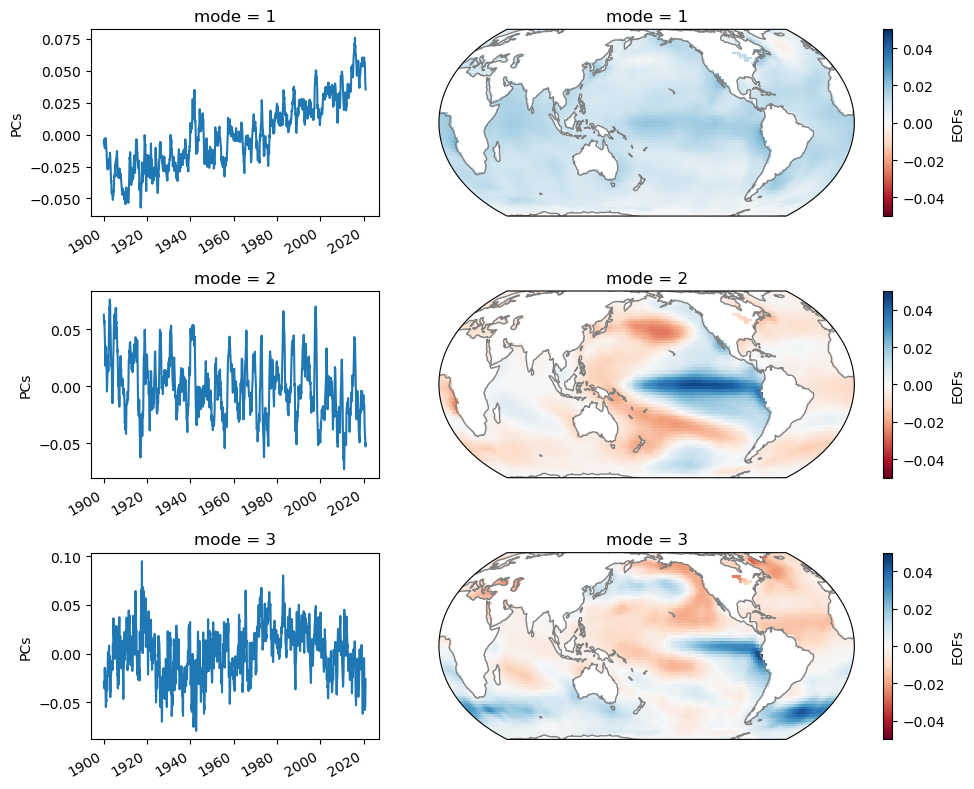

In [45]:

proj = EqualEarth(central_longitude = 180)
kwargs = {
    'cmap' : 'RdBu', 'vmin' : -.05, 'vmax': .05, 'transform': PlateCarree()
}

fig = plt.figure(figsize=(10, 8))
gs = GridSpec(3, 2, width_ratios=[1, 2])
ax0 = [fig.add_subplot(gs[i, 0]) for i in range(3)]
ax1 = [fig.add_subplot(gs[i, 1], projection=proj) for i in range(3)]

for i, (a0, a1) in enumerate(zip(ax0, ax1)):
    pcs.sel(mode=i+1).plot(ax=a0)
    a1.coastlines(color='.5')
    eofs.sel(mode=i+1).plot(ax=a1, **kwargs)

    a0.set_xlabel('')

plt.tight_layout()
#plt.savefig('eof-smode.jpg')

In [ ]:
#EOF lecture part 1 deterministic mode view Dr Dietmar Dommenget

exercise 2

In [47]:
ds = xr.open_dataset(r"C:\Users\USER\Desktop\MA\111-2\CAD\Week11\slp.mon.mean.nc")
# select period
ds = ds.sel(time=slice('1960', '2020'))
#actually load the data
ds.load()
#ds.to_netcdf("sst.mon.mean.oisstnan.nc")

<xarray.Dataset>
Dimensions:  (lat: 73, lon: 144, time: 732)
Coordinates:
  * lat      (lat) float32 90.0 87.5 85.0 82.5 80.0 ... -82.5 -85.0 -87.5 -90.0
  * lon      (lon) float32 0.0 2.5 5.0 7.5 10.0 ... 350.0 352.5 355.0 357.5
  * time     (time) datetime64[ns] 1960-01-01 1960-02-01 ... 2020-12-01
Data variables:
    slp      (time, lat, lon) float32 1.025e+03 1.025e+03 ... 989.7 989.7
Attributes:
    description:    Data is from NMC initialized reanalysis\n(4x/day).  These...
    platform:       Model
    Conventions:    COARDS
    NCO:            20121012
    history:        Thu May  4 18:12:35 2000: ncrcat -d time,0,622 /Datasets/...
    title:          monthly mean slp from the NCEP Reanalysis
    dataset_title:  NCEP-NCAR Reanalysis 1
    References:     http://www.psl.noaa.gov/data/gridded/data.ncep.reanalysis...

In [48]:
ds_climo = ds.groupby('time.month').mean()
ds_anoms = ds.groupby('time.month')-ds_climo
ds_anoms

<xarray.Dataset>
Dimensions:  (lat: 73, lon: 144, time: 732)
Coordinates:
  * lat      (lat) float32 90.0 87.5 85.0 82.5 80.0 ... -82.5 -85.0 -87.5 -90.0
  * lon      (lon) float32 0.0 2.5 5.0 7.5 10.0 ... 350.0 352.5 355.0 357.5
  * time     (time) datetime64[ns] 1960-01-01 1960-02-01 ... 2020-12-01
    month    (time) int64 1 2 3 4 5 6 7 8 9 10 11 ... 2 3 4 5 6 7 8 9 10 11 12
Data variables:
    slp      (time, lat, lon) float32 11.3 11.3 11.3 ... -8.243 -8.243 -8.243

In [51]:
ds_anoms = ds_anoms.reindex(lat = list(reversed(ds_anoms['lat'])))
ds_tpac = ds_anoms.sel(lat = slice(0,-90),lon = slice(0,360))

In [52]:
ds_tpac

<xarray.Dataset>
Dimensions:  (lat: 37, lon: 144, time: 732)
Coordinates:
  * lat      (lat) float32 0.0 -2.5 -5.0 -7.5 -10.0 ... -82.5 -85.0 -87.5 -90.0
  * lon      (lon) float32 0.0 2.5 5.0 7.5 10.0 ... 350.0 352.5 355.0 357.5
  * time     (time) datetime64[ns] 1960-01-01 1960-02-01 ... 2020-12-01
    month    (time) int64 1 2 3 4 5 6 7 8 9 10 11 ... 2 3 4 5 6 7 8 9 10 11 12
Data variables:
    slp      (time, lat, lon) float32 -0.2426 -0.2576 -0.2493 ... -8.243 -8.243

In [53]:
slp = ds_tpac['slp']

In [55]:
coslat = np.cos(np.deg2rad(slp.coords['lat'].values))
wgts = np.sqrt(coslat)[..., np.newaxis]
slp = slp*wgts

C:\Users\USER\AppData\Local\Temp\ipykernel_5080\1302872655.py:2: RuntimeWarning: invalid value encountered in sqrt
  wgts = np.sqrt(coslat)[..., np.newaxis]


In [56]:
#smode
model = EOF(slp, n_modes = 5, norm=False, dim='time')
model.solve()
expvar = model.explained_variance_ratio()
eofs = model.eofs()
pcs = model.pcs()

In [57]:
expvar * 100

<xarray.DataArray 'explained_variance_ratio' (mode: 5)>
array([27.34511351, 10.12733326,  8.47025094,  6.03512695,  5.04268058])
Coordinates:
  * mode     (mode) int32 1 2 3 4 5

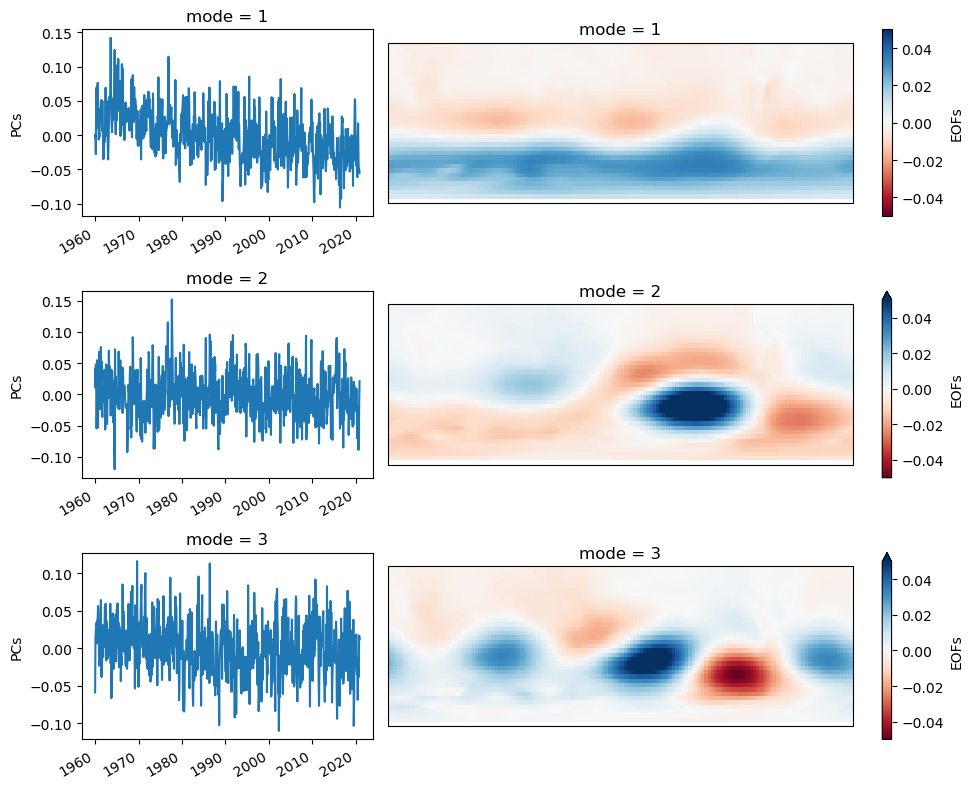

In [63]:

proj = EqualEarth(central_longitude = 0)
kwargs = {
    'cmap' : 'RdBu', 'vmin' : -.05, 'vmax': .05, 'transform': Orthographic()
}

fig = plt.figure(figsize=(10, 8))
gs = GridSpec(3, 2, width_ratios=[1, 2])
ax0 = [fig.add_subplot(gs[i, 0]) for i in range(3)]
ax1 = [fig.add_subplot(gs[i, 1], projection = proj) for i in range(3)]

for i, (a0, a1) in enumerate(zip(ax0, ax1)):
    pcs.sel(mode=i+1).plot(ax=a0)
    a1.coastlines(color='.5')
    eofs.sel(mode=i+1).plot(ax=a1, **kwargs)

    a0.set_xlabel('')

plt.tight_layout()
#plt.savefig('eof-smode.jpg')

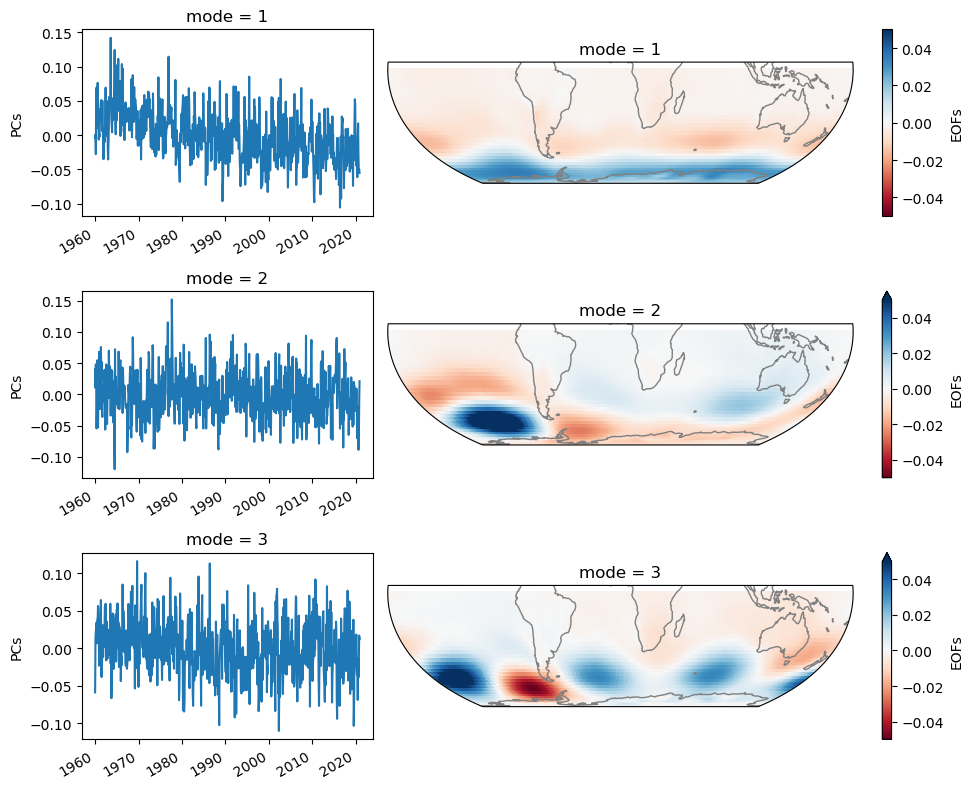

In [66]:

proj = EqualEarth(central_longitude = 0)
kwargs = {
    'cmap' : 'RdBu', 'vmin' : -.05, 'vmax': .05, 'transform': PlateCarree()
}

fig = plt.figure(figsize=(10, 8))
gs = GridSpec(3, 2, width_ratios=[1, 2])
ax0 = [fig.add_subplot(gs[i, 0]) for i in range(3)]
ax1 = [fig.add_subplot(gs[i, 1], projection = proj) for i in range(3)]

for i, (a0, a1) in enumerate(zip(ax0, ax1)):
    pcs.sel(mode=i+1).plot(ax=a0)
    a1.coastlines(color='.5')
    eofs.sel(mode=i+1).plot(ax=a1, **kwargs)

    a0.set_xlabel('')

plt.tight_layout()
#plt.savefig('eof-smode.jpg')

